<a href="https://colab.research.google.com/github/Rabia-Batool9/supervised-machine-learning-model/blob/main/rabia_btool_random_forecast7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Random Forest Algorithm on Loan Approval Dataset**

** Introduction**

Machine Learning is a branch of Artificial Intelligence that enables systems to learn from data and make predictions. One of the most powerful supervised learning algorithms is the Random Forest Algorithm.

Random Forest is an ensemble learning technique that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In this project, we use the Loan Approval Dataset to predict whether a loan application will be approved or rejected based on applicant information.

**Import Libraries**

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Load Dataset**

In [4]:
df = pd.read_csv("/content/loan_approval_dataset.csv")
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


**Display Dataset**

In [5]:
# First 5 Rows

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
# Dataset Shape

df.shape

(4269, 13)

In [7]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [8]:
# Check Missing Values

df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


# **Data Preprocessing**
Remove Extra Spaces from Column Names

In [9]:
df.columns = df.columns.str.strip()

**Encode Categorical Variables**

In [10]:
# Label Encoding

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**Exploratory Data Analysis (EDA)**
Statistical Summary

In [11]:
df.describe()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2135.000000,2.498712,0.497775,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.377840
std,1232.498479,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,1.000000,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1068.000000,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,2135.000000,3.000000,0.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,0.000000
75%,3202.000000,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,4269.000000,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


**Correlation Heatmap**

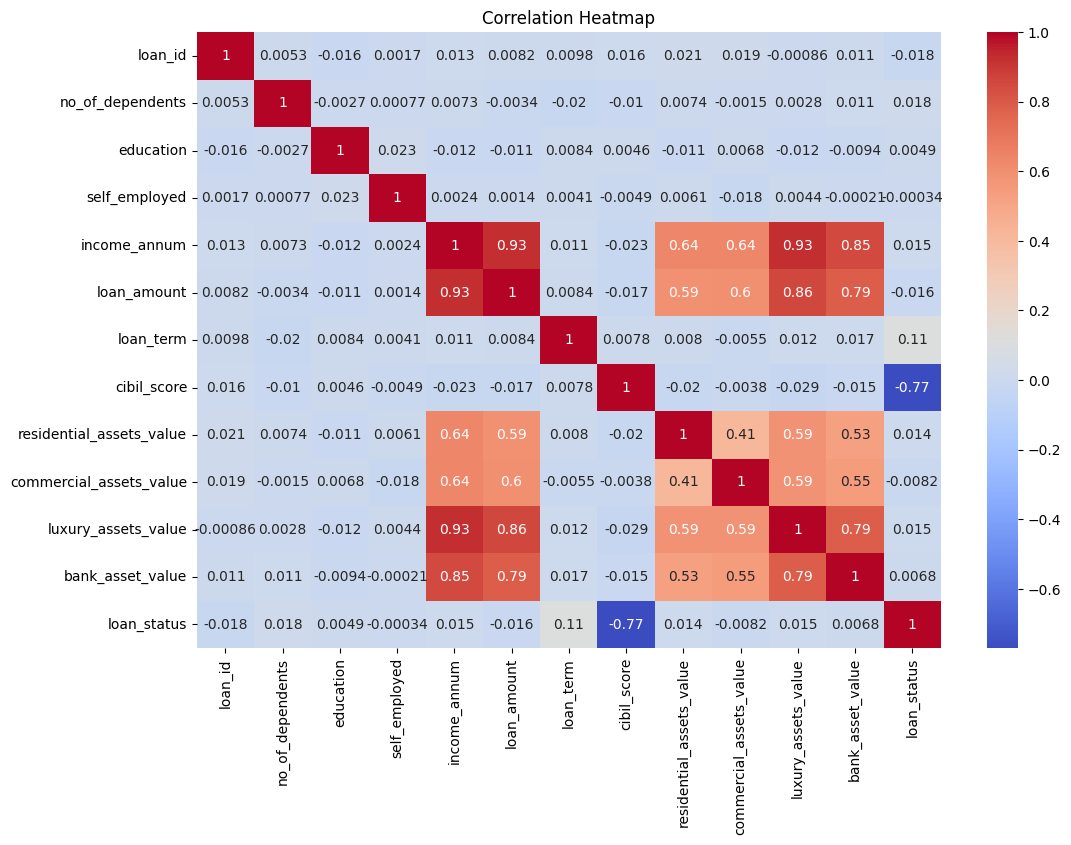

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Loan Status Count Plot

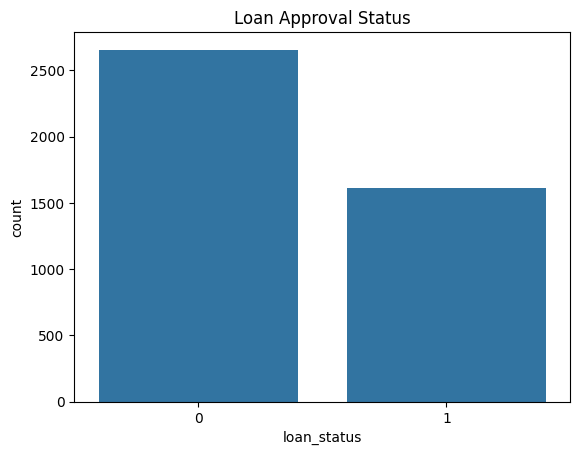

In [13]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Approval Status")
plt.show()

**Income Distribution**

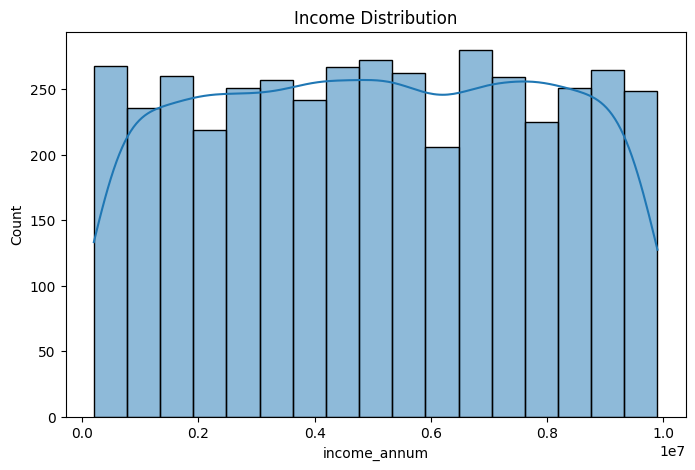

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['income_annum'], kde=True)
plt.title("Income Distribution")
plt.show()

**Loan Amount Distribution**

In [15]:
# Features

X = df.drop('loan_status', axis=1)

# Target

y = df['loan_status']

**Split Dataset**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Build Random Forest Model**

In [17]:
# Create Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Make Predictions**

In [18]:
# Predictions

y_pred = rf_model.predict(X_test)

# **Model Evaluation**
Accuracy Score

In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.9765807962529274


**Classification Report**

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854



**Confusion Matrix**

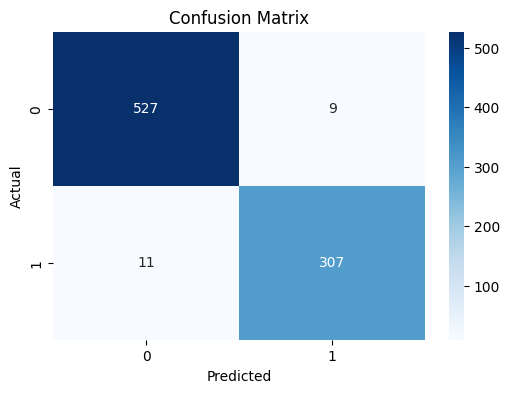

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Feature Importance

In [22]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                     Feature  Importance
7                cibil_score    0.801838
6                  loan_term    0.061950
5                loan_amount    0.027927
10       luxury_assets_value    0.016878
0                    loan_id    0.016761
4               income_annum    0.016043
8   residential_assets_value    0.015732
11          bank_asset_value    0.015719
9    commercial_assets_value    0.015258
1           no_of_dependents    0.007455
2                  education    0.002266
3              self_employed    0.002172


Feature Importance Visualization

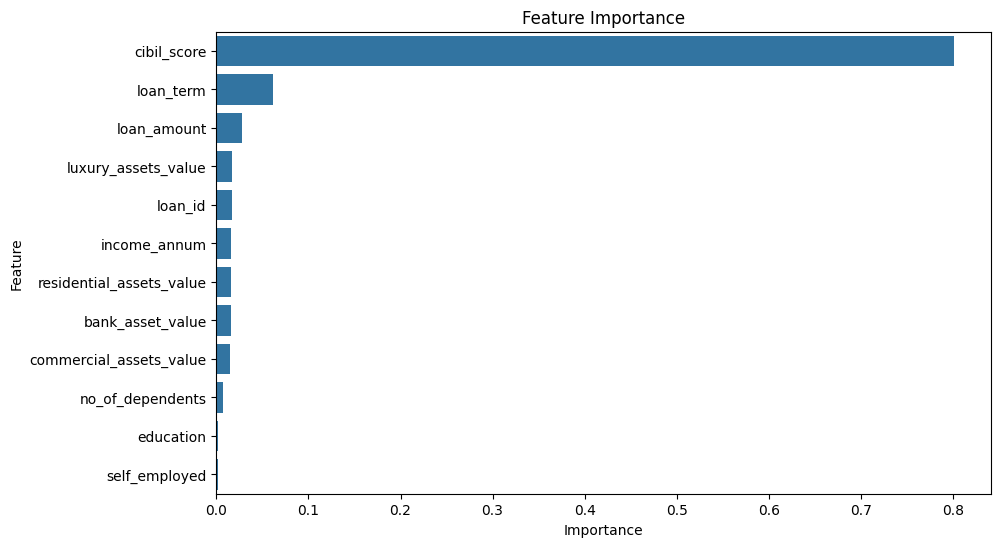

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

Insights & Findings

 Observations

Random Forest achieved very high prediction accuracy.
Income and credit-related features strongly affected loan approval.
The model handled both numerical and categorical data effectively.
Feature importance helped identify the most influential variables.

Insights

*  Applicants with higher income had better chances of loan approval.
*  Credit score/history played a major role in prediction.
*  Loan amount and applicant assets also influenced decisions.


# **Advantages of Random Forest**

High Accuracy
Reduces Overfitting
Handles Large Datasets
Works with Missing Values
Provides Feature Importance

# Conclusion

In this project, the Random Forest Algorithm was successfully implemented on the Loan Approval Dataset. The model effectively predicted loan approval status with high accuracy.

The project demonstrated the importance of preprocessing, visualization, model training, and evaluation in machine learning workflows. Random Forest proved to be a reliable and efficient algorithm for classification problems.